# Import libraries

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data

In [14]:
user_local_dir = "/home/maxence/dev/hardware/TMS/data_processing/20260217_TMS_Voltage_Pulse" # Change this to your local directory
file_name = "SDS00018.CSV" # CSV file name without extension

R = 0.3 # Resistance in Ohm

# Data directory
data_folder_dir = os.path.join(user_local_dir)
data_file_dir = os.path.join(data_folder_dir, f"{file_name}")
print(f"Data file directory: {data_file_dir}")

# Output directory
output_folder_dir = os.path.join(user_local_dir, "20260217_TMS_Voltage_Pulse/Output")
os.makedirs(output_folder_dir, exist_ok=True)
print(f"Output folder directory: {output_folder_dir}")

Data file directory: /home/maxence/dev/hardware/TMS/data_processing/20260217_TMS_Voltage_Pulse/SDS00018.CSV
Output folder directory: /home/maxence/dev/hardware/TMS/data_processing/20260217_TMS_Voltage_Pulse/20260217_TMS_Voltage_Pulse/Output


In [15]:
print(data_file_dir)

/home/maxence/dev/hardware/TMS/data_processing/20260217_TMS_Voltage_Pulse/SDS00018.CSV


In [16]:
data_csv = pd.read_csv(data_file_dir)
data_csv.head()

,Record Length,10000,Source,CH1
0,Sample Interval,CH1:0.0000000800000,Second,Volt
1,Vertical Units,CH1:V,-0.000372,24
2,Vertical Scale,CH1:10.00,-0.00037192,24
3,Vertical Offset,CH1:0.00,-0.00037184,24
4,Horizontal Units,s,-0.00037176,24


In [17]:
data = data_csv.loc[data_csv.index[1]:, ["Source", "CH1"]].astype(float).copy()
data.columns = ["Time [s]", "Voltage [V]"] # Rename columns
data = data.reset_index(drop=True) # Reset indices
data.head()

,Time [s],Voltage [V]
0,-0.000372,24.0
1,-0.000372,24.0
2,-0.000372,24.0
3,-0.000372,24.0
4,-0.000372,24.0


# Plot Voltage Pulse

In [18]:
# Crop data to pulse
pulse_start_ms, pulse_end_ms = -0.00015, 0.0005
data = data[(data["Time [s]"] >= pulse_start_ms) & (data["Time [s]"] <= pulse_end_ms)].copy()
data = data.reset_index(drop=True) # Reset indices
# set time 0 to 0s
data["Time [s]"] = data["Time [s]"] - data["Time [s]"].min()
data.head()

,Time [s],Voltage [V]
0,0.000000e+00,24.0
1,8.000000e-08,24.0
2,1.600000e-07,24.0
3,2.400000e-07,24.0
4,3.200000e-07,24.0


In [19]:
# get pulse length in ms
pulse_start_s = 75e-6 # found by looking at the data
pulse_end_s = 450e-6 # found by looking at the data

pulse_length_s = pulse_end_s - pulse_start_s
print(f"Pulse length: {pulse_length_s*1e6:.2f} us")

end_voltage = -0.8 # V found by looking at the data

# find where data crosses -0.8 V for the first time
zero_crossing_index = np.where(data["Voltage [V]"] <= end_voltage)[0][0]
zero_crossing_s = data.loc[zero_crossing_index, "Time [s]"]

# Calculate positive and negative lobe lengths
positive_lobe_length = zero_crossing_s - pulse_start_s
negative_lobe_length = pulse_end_s - zero_crossing_s
print(f"Positive lobe length: {positive_lobe_length*1e6:.2f} us")
print(f"Negative lobe length: {negative_lobe_length*1e6:.2f} us")

Pulse length: 375.00 us
Positive lobe length: 109.08 us
Negative lobe length: 265.92 us


In [20]:
# get dv/dt
tangent_points = [140e-6, 175e-6]
smoothing_window = 5

voltage_tangent_points = []
for point in tangent_points:
    # Find the index of the closest time point to the tangent point
    idx = (data["Time [s]"] - point).abs().idxmin()
    
    # Get the voltage values around the tangent point for smoothing
    start_idx = max(0, idx - smoothing_window)
    end_idx = min(len(data) - 1, idx + smoothing_window)
    
    # Calculate the average voltage in the smoothing window
    avg_voltage = data.loc[start_idx:end_idx, "Voltage [V]"].mean()
    
    voltage_tangent_points.append(avg_voltage)
print(f"Tangent points (time, voltage): {list(zip(tangent_points, voltage_tangent_points))}\n")

slope = (voltage_tangent_points[1] - voltage_tangent_points[0]) / (tangent_points[1] - tangent_points[0])
print(f"Slope (dv/dt): {slope/1e6:.2e} V/us")

Tangent points (time, voltage): [(0.00014, np.float64(13.67272727272727)), (0.000175, np.float64(2.4))]

Slope (dv/dt): -3.22e-01 V/us


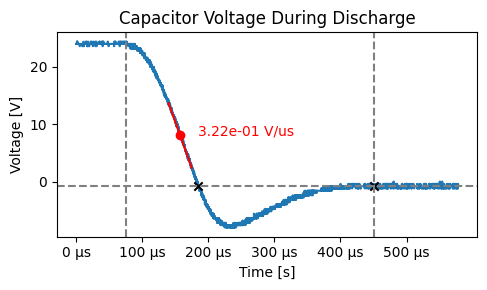

In [21]:
plt.figure(figsize=(5, 3))
plt.plot(data["Time [s]"], data["Voltage [V]"], zorder=-10)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")

# plot dv/dt tangent line
plt.scatter(np.mean(tangent_points), np.mean(voltage_tangent_points), color='red', label='Tangent Point')
plt.plot(tangent_points, voltage_tangent_points, color='red', linestyle='-', label='Tangent Line')
plt.text(np.mean(tangent_points)+1e-4, np.mean(voltage_tangent_points), f"{abs(slope)/1e6:.2e} V/us", color='red', ha='center')

# plot vertical line at pulse start
plt.axvline(x=pulse_start_s, color='gray', linestyle='--')
plt.axvline(x=pulse_end_s, color='gray', linestyle='--')

# plot horizontal line at 0 V
plt.axhline(y=-0.8, color='gray', linestyle='--')

# highlight zero crossings
plt.scatter(zero_crossing_s, end_voltage, marker="x", color='black', label='Zero Crossing')
plt.scatter(pulse_end_s, end_voltage, marker="x", color='black', label='Second Zero Crossing')

# set ticks in microseconds
plt.gca().set_xticks([i * 1e-6 for i in range(0, int(pulse_length_s*1e6)+200, 100)])
plt.gca().set_xticklabels([f"{i} µs" for i in range(0, int(pulse_length_s*1e6)+200, 100)])


plt.title("Capacitor Voltage During Discharge")

plt.tight_layout()

plt.savefig(os.path.join(output_folder_dir, f"{file_name}_TMScoil_voltage.svg"),
            dpi=300,              # high resolution
            bbox_inches='tight')  # removes extra white space
plt.show()
plt.close()

# Plot Current Pulse

In [22]:
from scipy.signal import savgol_filter

In [23]:
def calculate_didt_from_voltage(time, voltage, C, window_length=11, polyorder=3):
    """
    Calculates dI/dt from capacitor voltage pulse.
    """
    dt = time[1] - time[0]
    
    # Smooth and calculate the second derivative of voltage
    # savgol_filter can compute derivatives directly
    d2V_dt2 = savgol_filter(voltage, window_length, polyorder, deriv=2, delta=dt)
    
    didt = C * d2V_dt2
    return didt

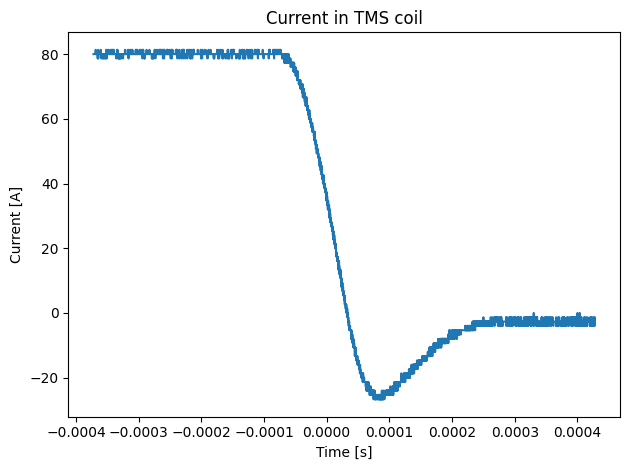

In [6]:
plt.figure()
plt.plot(data["Time [s]"], data["Current [A]"])
plt.xlabel("Time [s]")
plt.ylabel("Current [A]")
plt.title("Current in TMS coil")
plt.tight_layout()

plt.savefig(os.path.join(output_folder_dir, f"{file_name}_TMScoil_current.png"),
            dpi=300,              # high resolution
            bbox_inches='tight')  # removes extra white space
plt.show()
plt.close()